# Importar bibliotecas

Se hace esto pues las bibliotecas (también conocidas como módulos o paquetes) se importan para aprovechar el código previamente escrito por otros desarrolladores, funcionando como herramientas en el código propio.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import seaborn as sns
import warnings
import calendar
import locale
from mpl_toolkits.mplot3d import Axes3D
import re
import networkx as nx

# Importar dataset y hacer la lectura de este a través de pandas

## Dataset: Solicitud de medidas de protección por violencia intrafamiliar

*   Descripción: Es un dataset que recopila las solicitudes hechas a comisarías e inspecciones al interior de Medellín, entre el 2003 y el 2023, al respecto de incidentes de violencia intrafamiliar en los que fue necesaria la protección de estas instituciones.
*   Importancia para la ciencia política: Estos datos proporcionan información valiosa sobre la magnitud y la naturaleza de la violencia intrafamiliar en Medellín; por lo que, es información valiosa para la formulación de políticas pueden o programas de preveción más efectivos; también, permiten evaluar las políticas existentes pues permiten una definición y delimitación del problema con la que es posible contrastar los resultados, los diseños y la implementación. Por otro lado, como concibe un largo período de tiempo, puede ser usados para identificar tendencias y patrones en la violencia intrafamiliar, lo que puede ayudar a comprender mejor las causas subyacentes y las áreas geográficas con mayor incidencia, incidiendo direcatmente en la investigación disciplinar.
*   Fuente: https://medata.gov.co/dataset/1-027-23-000028








In [ ]:
df = pd.read_csv("violencia_intrafamiliar.csv" , delimiter = "," , dtype='object')
df.shape

(91697, 36)

*   En la primer línea se identifica el dataset con el nombre "df", y se indica que se leerá el formato csv (que tiene un espaciador de coma sencilla) con la librería pandas; además, se especifica que el contenido sea leído en el dtype "object" que permite los datos heterogéneos, unificando desde ya la información.
*   La segunda línea se utiliza para ver el tamaño del dataset en términos de filas y columnas.



# Exploración del dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91697 entries, 0 to 91696
Data columns (total 36 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   fecha_hecho          91697 non-null  object
 1   cantidad             91697 non-null  object
 2   latitud              70394 non-null  object
 3   longitud             70392 non-null  object
 4   sexo                 91697 non-null  object
 5   edad                 91697 non-null  object
 6   estado_civil         91697 non-null  object
 7   grupo_actor          91697 non-null  object
 8   actividad_delictiva  91697 non-null  object
 9   parentesco           91697 non-null  object
 10  ocupacion            91697 non-null  object
 11  discapacidad         91697 non-null  object
 12  grupo_especial       91697 non-null  object
 13  medio_transporte     91697 non-null  object
 14  nivel_academico      91697 non-null  object
 15  testigo              91697 non-null  object
 16  cond

*   Con esta función (.info) se puede conocer el contenido del dataset, donde aparecen los nombres de las columnas, la cantidad de datos sin rellenar y el tipo de tipología en la columna.
*   Se puede observar que los nombres de las columnas tienen una redacción consistente, y solo dos de ellas (longitud y latitud) tienen filas con vacíos de información.





In [ ]:
df.head()

,fecha_hecho,cantidad,latitud,longitud,sexo,edad,estado_civil,grupo_actor,actividad_delictiva,parentesco,...,lugar,sede_receptora,bien,categoria_bien,grupo_bien,modelo,color,permiso,unidad_medida,fecha_ingestion
0,2003-07-25T00:00:00.000-05:00,1.0,6.300601,-75.550253,Mujer,27,Casado(a),Sin dato,Sin dato,Sin dato,...,Residencia,Comisaría 2 - villa del socorro,Sin dato,Sin dato,Sin dato,Sin dato,Sin dato,Sin dato,Sin dato,2023-10-26T15:19:01.000-05:00
1,2003-07-25T00:00:00.000-05:00,1.0,6.300601,-75.550253,Mujer,53,Casado(a),Sin dato,Sin dato,Sin dato,...,Residencia,Comisaría 2 - villa del socorro,Sin dato,Sin dato,Sin dato,Sin dato,Sin dato,Sin dato,Sin dato,2023-10-26T15:19:01.000-05:00
2,2003-12-01T00:00:00.000-05:00,1.0,NaN,NaN,Sin dato,22,Casado(a),Sin dato,Sin dato,Sin dato,...,Sin dato,Inspección 10b - boston,Sin dato,Sin dato,Sin dato,Sin dato,Sin dato,Sin dato,Sin dato,2023-10-26T15:19:01.000-05:00
3,2003-12-12T00:00:00.000-05:00,1.0,NaN,NaN,Mujer,44,Unión marital de hecho,Sin dato,Sin dato,Sin dato,...,Residencia,Comisaría san antonio de prado,Sin dato,Sin dato,Sin dato,Sin dato,Sin dato,Sin dato,Sin dato,2023-10-26T15:19:01.000-05:00
4,2003-12-12T00:00:00.000-05:00,1.0,NaN,NaN,Hombre,17,Soltero(a),Sin dato,Sin dato,Sin dato,...,Residencia,Comisaría san antonio de prado,Sin dato,Sin dato,Sin dato,Sin dato,Sin dato,Sin dato,Sin dato,2023-10-26T15:19:01.000-05:00




*   Se usa .head() para acceder a la visualización de las primeras 5 filas de todas las columnas, lo que permite entender con mayor profundidad los datos que componen al dataset.
*   Como resultado, se observa que hay varias columnas que tienen información faltante que aparece como "sin dato"; también, se observa que le formato de las columnas que incluyen fechas es un poco extenso y dificulta su comprensión. Además de eso, los datos son coherentes, constantes y entendibles, por lo que e sposible trabajar con el dataset.


In [ ]:
df.tail()

,fecha_hecho,cantidad,latitud,longitud,sexo,edad,estado_civil,grupo_actor,actividad_delictiva,parentesco,...,lugar,sede_receptora,bien,categoria_bien,grupo_bien,modelo,color,permiso,unidad_medida,fecha_ingestion
91692,2019-12-31T00:00:00.000-05:00,1.0,6.27082603,-75.5466035,Mujer,39,Unión marital de hecho,Sin dato,Sin dato,Sin dato,...,Residencia,Comisaría 3 - manrique,Sin dato,Sin dato,Sin dato,Sin dato,Sin dato,Sin dato,Sin dato,2023-10-26T15:19:01.000-05:00
91693,2019-12-31T00:00:00.000-05:00,1.0,6.26618582,-75.55292284,Mujer,26,Unión marital de hecho,Sin dato,Sin dato,Sin dato,...,Residencia,Permanencia 1 el bosque,Sin dato,Sin dato,Sin dato,Sin dato,Sin dato,Sin dato,Sin dato,2023-10-26T15:19:01.000-05:00
91694,2019-12-31T00:00:00.000-05:00,1.0,6.27261743,-75.54999779,Mujer,20,Soltero(a),Sin dato,Sin dato,Sin dato,...,Vía pública,Permanencia 1 el bosque,Sin dato,Sin dato,Sin dato,Sin dato,Sin dato,Sin dato,Sin dato,2023-10-26T15:19:01.000-05:00
91695,2019-12-31T00:00:00.000-05:00,1.0,6.24764763,-75.54035214,Mujer,26,Soltero(a),Sin dato,Sin dato,Sin dato,...,Residencia,Comisaría 8 - villa hermosa,Sin dato,Sin dato,Sin dato,Sin dato,Sin dato,Sin dato,Sin dato,2023-10-26T15:19:01.000-05:00
91696,2019-12-31T00:00:00.000-05:00,1.0,6.30350253,-75.58317212,Mujer,32,Soltero(a),Sin dato,Sin dato,Sin dato,...,Residencia,Comisaría 6 - 12 de octubre,Sin dato,Sin dato,Sin dato,Sin dato,Sin dato,Sin dato,Sin dato,2023-10-26T15:19:01.000-05:00


* Se usa .tail() para acceder a la visualización de las últimas 5 filas de todas las columnas, lo que permite entender con mayor profundidad los datos que componen al dataset.
*   Se hizo esto para comparar la información que está al inicio del dtataset, y la que se aloja al final.
*   De esto, se pudo concluir que hay columnas enteras que están compuestas por la cadena "sin dato", así que con esas columnas no es ideal trabajar pues no aporta ninguna información.



# Selección de columnas

En este paso, se seleccionarán 8 columnas, 4 cuantitativas y 4 cualitativas, que se consideran aptas para el trabajo por la calidad de la información que poseen.

In [ ]:
columnas_seleccionadas = ['fecha_hecho', 'latitud', 'longitud' , 'edad' , 'sexo' , 'estado_civil' , 'lugar' , 'sede_receptora']
new_df = df[columnas_seleccionadas]

*   En la primera línea se iguala el comando "columnas_seleccionadas" con las 8 columnas que se esocge del dataset.
*   En la segunda, se indica que se crea un nuevo dataset que se desprende del dataset anterior llamado "new_df". Y, se le dice que su contenido serán las 8 columnas seleccionadas.






In [ ]:
new_df.head()

,fecha_hecho,latitud,longitud,edad,sexo,estado_civil,lugar,sede_receptora
0,2003-07-25T00:00:00.000-05:00,6.300601,-75.550253,27,Mujer,Casado(a),Residencia,Comisaría 2 - villa del socorro
1,2003-07-25T00:00:00.000-05:00,6.300601,-75.550253,53,Mujer,Casado(a),Residencia,Comisaría 2 - villa del socorro
2,2003-12-01T00:00:00.000-05:00,NaN,NaN,22,Sin dato,Casado(a),Sin dato,Inspección 10b - boston
3,2003-12-12T00:00:00.000-05:00,NaN,NaN,44,Mujer,Unión marital de hecho,Residencia,Comisaría san antonio de prado
4,2003-12-12T00:00:00.000-05:00,NaN,NaN,17,Hombre,Soltero(a),Residencia,Comisaría san antonio de prado


*   Es el mismo paso realizado anteriormente. Esta vez permite observar que en las columnas seleccionadas hay una combinación de datos numéricos y cadenas de texto, así como ya no están las columnas conformadas por "sin dato".



In [ ]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91697 entries, 0 to 91696
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   fecha_hecho     91697 non-null  object
 1   latitud         70394 non-null  object
 2   longitud        70392 non-null  object
 3   edad            91697 non-null  object
 4   sexo            91697 non-null  object
 5   estado_civil    91697 non-null  object
 6   lugar           91697 non-null  object
 7   sede_receptora  91697 non-null  object
dtypes: object(8)
memory usage: 5.6+ MB


# Limpieza del dataset

## Columna: fecha_hecho
Descripción: Fecha del suceso de violencia intrafamiliar.

Tipo de variable: cuantitativa discreta, pues ni el año, ni el mes ni el día se pueden dividir en fracciones infinitamente pequeñas, en tanto representan valores enteros que corresponden a momentos específicos en el calendario.

In [ ]:
new_df['fecha_hecho'] = pd.to_datetime(new_df['fecha_hecho']).dt.strftime('%Y-%m-%d')
new_df['fecha_hecho'] = pd.to_datetime(new_df['fecha_hecho'])

<ipython-input-11-a58eedb724c5>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['fecha_hecho'] = pd.to_datetime(new_df['fecha_hecho']).dt.strftime('%Y-%m-%d')
<ipython-input-11-a58eedb724c5>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['fecha_hecho'] = pd.to_datetime(new_df['fecha_hecho'])


*   En este código, pd.to_datetime() se usa para convertir la columna fecha_hecho en un objeto DateTime, y luego .dt.strftime('%Y-%m-%d') se utiliza para formatear las fechas en el formato "YYYY-MM-DD". El resultado se almacena nuevamente en la columna fecha_hecho.
*   Se hace este paso para convertir la información de la columna en información más legible, permitiendo un formato donde solo se ve la fecha (año, més, día).



In [ ]:
new_df['ano'] = new_df['fecha_hecho'].dt.year
new_df['mes'] = new_df['fecha_hecho'].dt.month
new_df['dia'] = new_df['fecha_hecho'].dt.day

<ipython-input-12-d2b4ecc3d631>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['ano'] = new_df['fecha_hecho'].dt.year
<ipython-input-12-d2b4ecc3d631>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['mes'] = new_df['fecha_hecho'].dt.month
<ipython-input-12-d2b4ecc3d631>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-do

*   Se busca separar cada elemento de la columna como dato independiente, esto se hace solo porue posteriormente puede ser útil tener los datos separados




## Columna: latitud
Descripción: Latitud del lugar donde ocurrió el incidente de violencia intrafamiliar.

Tipo de variable: cuantitativa continua, pues no solo es decimal sino que puede tomar cualquier valor (incluso negativo).

In [ ]:
new_df['latitud'].fillna("0", inplace=True)

<ipython-input-13-ec018bc63df2>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['latitud'].fillna("0", inplace=True)


*   Este código usa el método fillna para reemplazar los valores nulos en la columna "latitud" con el valor "0"; además, el argumento inplace=True modifica el DataFrame original en su lugar. Después de ejecutar este código, las casillas vacías en la columna "latitud" contendrán "0" en lugar de NaN (valores nulos).
*   Como en las pasos anteriores se vio que esta columna tenía información faltante, y al ser una casilla numérica, se optó por rellenar las filas vacías por el valor 0.



In [ ]:
new_df['latitud'] = new_df['latitud'].replace("0.0", "0")

<ipython-input-14-2be22e7cc52c>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['latitud'] = new_df['latitud'].replace("0.0", "0")


*   Se usa la herramienta .replace() para que los valores que reportaban un 0.0 ahora queden en 0, siendo automáticamente agrupados con los valores agregados en las filas faltantes.
*   Esto se hace porque el punto 0.0 no corresponde a ningún punto de Medellín, así que el dato parece haber sido tomado mal y se le agrupa con otro indicador.



In [ ]:
new_df['latitud'] = new_df['latitud'].astype(float)
new_df['latitud'] = new_df['latitud'].round(2)

<ipython-input-15-464537f04d3e>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['latitud'] = new_df['latitud'].astype(float)
<ipython-input-15-464537f04d3e>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['latitud'] = new_df['latitud'].round(2)


*   Este código primero convierte la columna "latitud" a tipo float usando astype(float) puesto que la columna representa números decimales. Luego aplica el redondeo a dos decimales con el round(2); aquí, el valor "0" será reemplazada automáticamente por un "0.00".
*   Se hace esto porque los valores de la columna implicaban muchos decimales, y si bien esto influye en la especifidad de la locación, también genera una cantidad de datos con los que trabajar o hacer gráficas se vuelve difícil. Por ello, se prefirió acortar la cantidad de decimales, generando que los datos se agrupen ellos mismo con esta nueva clasificación.
*   Para este paso, era importante que toda la información de la columna fuera numérica. Fue por ello que los datos faltantes o mal tomados se agruparon bajo "0".






## Columna: longitud
Descripción: Longitud del lugar donde ocurrió el incidente de violencia intrafamiliar.

Tipo de variable: cuantitativa continua, pues no solo es decimal sino que puede tomar cualquier valor (incluso negativo).

Esta columna tiene la misma cantidad de datos sin rellenar que la columna "latitud", además de que sucede los mismo con la existencia de filas con el valor "0.0". Por ello, se aplicaron los mismos pasos que se hicieron con la columna anterior.

In [ ]:
new_df['longitud'].fillna("0", inplace=True)

<ipython-input-16-bf56d18a9fd4>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['longitud'].fillna("0", inplace=True)


In [ ]:
new_df['longitud'] = new_df['longitud'].replace("0.0", "0")

<ipython-input-17-53b7cf732842>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['longitud'] = new_df['longitud'].replace("0.0", "0")


In [ ]:
new_df['longitud'] = new_df['longitud'].astype(float)
new_df['longitud'] = new_df['longitud'].round(2)

<ipython-input-18-261f07fc0ea3>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['longitud'] = new_df['longitud'].astype(float)
<ipython-input-18-261f07fc0ea3>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['longitud'] = new_df['longitud'].round(2)


## Columna: edad
Descripción: Edad de la víctima en el caso de violencia intrafamiliar.

Tipo de variable: cuantitativa discreta, ya que si bien está representada en la escala numérica, esta no puede tomar cualquier valor ya que solo se mide en años como número entero.

In [ ]:
new_df['edad'] = pd.to_numeric(new_df['edad'], errors='coerce')

<ipython-input-19-4c16aa273bc5>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['edad'] = pd.to_numeric(new_df['edad'], errors='coerce')


*   El código anterior corresponde a la necesidad de cambiar el tipo de dato, pues como al incio se estableció en dtype object, en esta columna los datos son únicamente numéricos. Se utiliza pd.to_numeric() con el argumento errors='coerce' para intentar convertir los valores a números. Los valores no numéricos se convertirán a NaN.
*   Se utiliza pd.to_numeric() con el argumento errors='coerce' para intentar convertir los valores a números. Los valores no numéricos, en caso de que los haya, se convertirán a NaN.





## Columna: sexo
Descripción: Sexo de la víctima.

Tipo de variable: cualitativa nominal, en tanto es una categoría donde no importa el orden.

In [ ]:
new_df.rename(columns={'sexo': 'sexo_medico'}, inplace=True)

<ipython-input-20-028ccb7cc902>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df.rename(columns={'sexo': 'sexo_medico'}, inplace=True)


*   El parámetro columns del método rename toma un diccionario en el que la clave es el nombre actual de la columna que se desea cambiar y el valor es el nuevo nombre de la columna. Además, se aplica el parámetro inplace=True, que hace que el cambio se realice en new_df.
*   Se hace esto porque el dato tomado solo distingue entre hombre y mujer, sin considerar otras exprexiones sexo-genéricas, o la distinción entre sexo y género. Por ello, el nombre sexo_medico indica de mejor manera el dato recolectado.



Adeás de esto, se considera que la columna está suficientemente limpia, pues no tiene filas vacías, errores ortográficos o gramaticales, y el tipo de dato es consistente y coherente.

## Columna: estado_civil
Descripción: Estado civil de la víctima.

Tipo de variable: cualitativa nominal, gracias a que no hay un orden natural entre las categorías del estado civil.

Se considera que la columna está suficientemente limpia, pues no tiene filas vacías, errores ortográficos o gramaticales, y el tipo de dato es consistente y coherente.

## Columna: lugar
Descripción: Tipología del lugar donde se dio el hecho de violencia inrafamiliar.

Tipo de variable: cualitativa nominal, pues los datos que se consideran no tienen un orden establecido.

Se considera que la columna está suficientemente limpia, pues no tiene filas vacías, errores ortográficos o gramaticales, y el tipo de dato es consistente y coherente.

## Columna: sede_receptora
Descripción: Sede de la policía que recibió la solicitud de protección ante un caso de violencia intrafamiliar.

Tipo de variable: cualitativa ordinal, pues si bien son nombres que no se ubican en la escala numérica, sí llevan un orden intrínseco que no puede ser cuantificable.

In [ ]:
new_df['sede_receptora']=df['sede_receptora']

<ipython-input-21-37c40efb503f>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['sede_receptora']=df['sede_receptora']


In [ ]:
new_df['sede_receptora'] = new_df['sede_receptora'].str.replace('-', ' ')
def capitalizar_palabras(texto):
    palabras = texto.split()
    palabras_capitalizadas = [palabra.capitalize() if palabra.lower() not in ['de', 'el', 'la'] else palabra for palabra in palabras]
    return ' '.join(palabras_capitalizadas)
new_df['sede_receptora'] = new_df['sede_receptora'].apply(capitalizar_palabras)

<ipython-input-22-03578db931cd>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['sede_receptora'] = new_df['sede_receptora'].str.replace('-', ' ')
<ipython-input-22-03578db931cd>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['sede_receptora'] = new_df['sede_receptora'].apply(capitalizar_palabras)


*   El primer código reemplaza el guion "-" por el espacio " " en la columna "sede_receptora".  Luego, utiliza la función apply() para aplicar la función titlecase_except() a cada fila de la columna; veáse que, la función titlecase_except() divide la cadena en palabras, capitaliza todas las palabras excepto las palabras en la lista de excepciones ("de" y "el"), y luego las une nuevamente en una sola cadena.
*   Esto se hace para igualar todas las frases (hay unas que contienen "-" y otras que no), respetando que son nombres de lugares y por ello deberían empezar con mayúsculas.





In [ ]:
new_df['sede_receptora'] = new_df['sede_receptora'].str.replace(r'^(\D+\s\d+\w*)', r'\1 /', regex=True)

<ipython-input-23-44f2a5e7fca5>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['sede_receptora'] = new_df['sede_receptora'].str.replace(r'^(\D+\s\d+\w*)', r'\1 /', regex=True)


*   En este código, se utiliza una expresión regular para buscar el primer número seguido de un espacio en cada fila de la columna 'sede_receptora', y luego lo reemplaza con el mismo número y un espacio seguido de "/". Además, la expresión regular ^(\D+\s\d+\w*) busca una parte no numérica \D+, seguida de uno o más dígitos \d+, seguidos opcionalmente por caracteres alfanuméricos; esto asegurará que se mantenga la letra junto al número cuando esté presente en el formato.
*   Esta es una decisión estética, pues se considera que los datos serán leídos de mejor manera si se separa el tipo de sede (comisaría e inspección), del lugar en donde está ubicada.



# Herramientas estadísticas

- Frecuencia absoluta y relativa: La frecuencia absoluta se refiere al número de veces que ocurre un valor específico en un conjunto de datos. La frecuencia relativa es una medida que expresa la proporción de veces que ocurre un valor en relación con el tamaño total del conjunto de datos.

Medidas de tendencia central:

- Media (promedio): La media es la suma de todos los valores en un conjunto de datos dividida por el número de valores.
- Mediana: La mediana es el valor que se encuentra en el centro de un conjunto de datos cuando se ordena de menor a mayor.
- Moda: La moda es el valor que aparece con mayor frecuencia en un conjunto de datos.

Medidas de dispersión:

- Rango: El rango es la diferencia entre el valor máximo y el valor mínimo en un conjunto de datos.
- Varianza: La varianza mide cuánto se alejan los valores individuales del valor medio (media) de los datos.
- Desviación estándar: La desviación estándar es simplemente la raíz cuadrada de la varianza. Proporciona una medida de la dispersión en las mismas unidades que los datos originales, lo que la hace más interpretable que la varianza.
- Rango intercuartil (IQR): El IQR es la diferencia entre el tercer cuartil (Q3) y el primer cuartil (Q1) en un conjunto de datos.
- Coeficiente de variación (CV): El coeficiente de variación es una medida de la variabilidad relativa de los datos y se expresa como un porcentaje. Se calcula dividiendo la desviación estándar por la media y multiplicando por 100. Es útil para comparar la variabilidad entre conjuntos de datos con diferentes escalas o magnitudes.

## fecha_hecho

### Frecuencias absolutas y relativas

In [ ]:
freq_unit_new_df = new_df['fecha_hecho'].value_counts().reset_index()
freq_unit_new_df.columns = ['fecha_hecho', 'frecuencia_absoluta']
freq_unit_new_df['frecuencia_relativa'] = freq_unit_new_df['frecuencia_absoluta'] / len(new_df)
freq_unit_new_df

,fecha_hecho,frecuencia_absoluta,frecuencia_relativa
0,2005-06-26,56,0.000611
1,2015-10-19,47,0.000513
2,2005-01-01,44,0.000480
3,2012-03-04,43,0.000469
4,2005-10-02,43,0.000469
...,...,...,...
6711,2004-10-17,1,0.000011
6712,2004-10-23,1,0.000011
6713,2017-12-21,1,0.000011
6714,2008-02-07,1,0.000011


- Primero, se utiliza value_counts() para contar cuántas veces aparece cada valor único en la columna 'fecha_hecho', generando un nuevo DataFrame llamado 'freq_unit_new_df'. Luego, se renombran las columnas de este nuevo DataFrame como 'fecha_hecho' y 'frecuencia_absoluta'. Posteriormente, se calcula la frecuencia relativa dividiendo la frecuencia absoluta entre el número total de filas en 'new_df' y se agrega esta información como una nueva columna llamada 'frecuencia_relativa' en 'freq_unit_new_df'.
---
- Se observa que al agrupar los datos de esta manera (eliminanado la hora), se reduce la cantidad de datos pues aumenta su coincidencia, permitiendo un mejor análisis.
- La fecha más repetida es "2005-06-26", e incluso así sólo representa el 0,0611%, lo que sugiere que ha muchos datos únicos o muy poco repetidos.


### Medidas de tendencia central

In [ ]:
# Calcular la media
media_año_fecha_hecho = new_df['ano'].mean()
media_mes_fecha_hecho = new_df['mes'].mean()
media_día_fecha_hecho = new_df['dia'].mean()

# Calcular la mediana
mediana_año_fecha_hecho = new_df['ano'].median()
mediana_mes_fecha_hecho = new_df['mes'].median()
mediana_día_fecha_hecho = new_df['dia'].median()

# Calcular la moda
moda_año_fecha_hecho = new_df['ano'].mode().values[0]
moda_mes_fecha_hecho = new_df['mes'].mode().values[0]
moda_día_fecha_hecho = new_df['dia'].mode().values[0]

# Imprimir los resultados
print("Media del año del hecho:", media_año_fecha_hecho)
print("Media del mes del hecho:", media_mes_fecha_hecho)
print("Media del día del hecho:", media_día_fecha_hecho)
print("Mediana del año del hecho:", mediana_año_fecha_hecho)
print("Mediana del mes del hecho:", mediana_mes_fecha_hecho)
print("Mediana del día del hecho:", mediana_día_fecha_hecho)
print("Moda del año del hecho:", moda_año_fecha_hecho)
print("Moda del mes del hecho:", moda_mes_fecha_hecho)
print("Moda del día del hecho:", moda_día_fecha_hecho)

Media del año del hecho: 2013.5453177312236
Media del mes del hecho: 6.454714985223072
Media del día del hecho: 15.586409588099938
Mediana del año del hecho: 2013.0
Mediana del mes del hecho: 6.0
Mediana del día del hecho: 16.0
Moda del año del hecho: 2005
Moda del mes del hecho: 1
Moda del día del hecho: 1


- La función mean() se usa para calcular la media de los valores en las columnas, median() se utiliza para encontrar la mediana, y mode() se emplea para obtener la moda. Finalmente, los resultados se imprimen en la consola para cada una de las medidas estadísticas calculadas, proporcionando información sobre el promedio, el valor que se encuentra en el centro y el valor más frecuente en cada una de las columnas especificadas.
- Se calcularon con las tres columnas extraídas pues no es posible hacer los cálculos necesarios con datos tipo "YYYY-MM-DD".
---
- La media del año del hecho es aproximadamente 2013.55, lo que sugiere que, en promedio, estos eventos ocurrieron en el año 2013. La mediana del año del hecho es 2013.0, lo que significa que la mitad de los eventos ocurrieron en o antes de 2013 y la otra mitad ocurrió en o después de 2013. La moda del año del hecho es 2005, lo que indica que 2005 es el año en que más casos se dieron.
- La media del mes del hecho es aproximadamente 6.45, lo que sugiere que, en promedio, estos eventos ocurrieron alrededor de junio. La moda del mes del hecho es 1, lo que indica que enero es el mes que más veces se repite en los datos.
- La media del día del hecho es aproximadamente 15.59, lo que sugiere que, en promedio, estos eventos ocurrieron alrededor del día 16 del mes. La moda del día del hecho es 1, lo que indica que el día 1 es el día que más veces se repite en los datos.






### Medidas de dispersión

In [ ]:
#Rango
rango_año = new_df['ano'].max() - new_df['ano'].min()
rango_mes = new_df['mes'].max() - new_df['mes'].min()
rango_día = new_df['dia'].max() - new_df['dia'].min()

#Varianza
varianza_año = new_df['ano'].var()
varianza_mes = new_df['mes'].var()
varianza_día = new_df['dia'].var()

#Desviación estándar
desviacion_estandar_año = new_df['ano'].std()
desviacion_estandar_mes = new_df['mes'].std()
desviacion_estandar_día = new_df['dia'].std()

#Rango intercuartil
q1 = new_df['ano'].quantile(0.25)
q3 = new_df['ano'].quantile(0.75)
iqr = q3 - q1

q1 = new_df['mes'].quantile(0.25)
q3 = new_df['mes'].quantile(0.75)
iqr = q3 - q1

q1 = new_df['dia'].quantile(0.25)
q3 = new_df['dia'].quantile(0.75)
iqr = q3 - q1

#Coeficiente de variación
coeficiente_variacion_año = (desviacion_estandar_año / media_año_fecha_hecho) * 100
coeficiente_variacion_mes = (desviacion_estandar_mes / media_mes_fecha_hecho) * 100
coeficiente_variacion_día = (desviacion_estandar_día / media_día_fecha_hecho) * 100

print("Rango año:", rango_año)
print("Rango mes:", rango_mes)
print("Rango día:", rango_día)

print("Varianza año:", varianza_año)
print("Varianza mes:", varianza_mes)
print("Varianza día:", varianza_día)

print("Desviación estándar año:", desviacion_estandar_año)
print("Desviación estándar mes:", desviacion_estandar_mes)
print("Desviación estándar día:", desviacion_estandar_día)

print("Coeficiente de variación año:", coeficiente_variacion_año)
print("Coeficiente de variación mes:", coeficiente_variacion_mes)
print("Coeficiente de variación día:", coeficiente_variacion_día)

Rango año: 20
Rango mes: 11
Rango día: 30
Varianza año: 28.858357312946048
Varianza mes: 11.888699659485024
Varianza día: 77.83438300066186
Desviación estándar año: 5.371997516096415
Desviación estándar mes: 3.447999370574917
Desviación estándar día: 8.82237966767821
Coeficiente de variación año: 0.2667929779772402
Coeficiente de variación mes: 53.418305509515164
Coeficiente de variación día: 56.603027257887575


- Para el rango, new_df['...'].max() devuelve el valor máximo de la columna 'ano', y new_df['...'].min() devuelve el valor mínimo de la misma columna.
- La función var() de pandas realiza automáticamente los cálculos necesarios, teniendo en cuenta la media de la columna para determinar la dispersión de los datos.
- La función std() de pandas realiza automáticamente los cálculos necesarios.
- q1 y q3 representan el primer cuartil (25%) y el tercer cuartil (75%) de la columna 'ano', respectivamente, y iqr es el rango intercuartil, que es la diferencia entre estos dos valores.
- coeficiente_variacion calcula el coeficiente de variación expresado como un porcentaje.
---
- El rango del año es de 20, lo que significa que la diferencia entre el año máximo (2023) y el año mínimo (2003) en los datos es de 20 años. El rango del mes es de 11, lo que indica que los eventos ocurrieron alrededor del año; igualmente, el rango del día es de 30, lo que sugiere que los eventos ocurrieron a lo largo del mes.
- La varianza del año es aproximadamente 28.86, lo que indica una dispersión moderada de los eventos a lo largo de los años. La varianza del mes es aproximadamente 11.89, lo que sugiere una dispersión moderada de los eventos a lo largo de los meses. La varianza del día es aproximadamente 77.83, lo que indica una dispersión considerable de los eventos a lo largo de los días.
- La desviación estándar del año es aproximadamente 5.37, lo que indica la dispersión promedio de los eventos en años. La desviación estándar del mes es aproximadamente 3.45, lo que indica la dispersión promedio de los eventos en meses. La desviación estándar del día es aproximadamente 8.82, lo que indica una dispersión considerable de los eventos en días.
- El coeficiente de variación del año es relativamente bajo (0.27), lo que sugiere que la variabilidad en los años es baja en comparación con la media. El coeficiente de variación del mes es bastante alto (53.42), lo que indica una variabilidad significativa en los meses en relación con la media. El coeficiente de variación del día también es alto (56.60), lo que sugiere una variabilidad significativa en los días en relación con la media.






### Gráficos

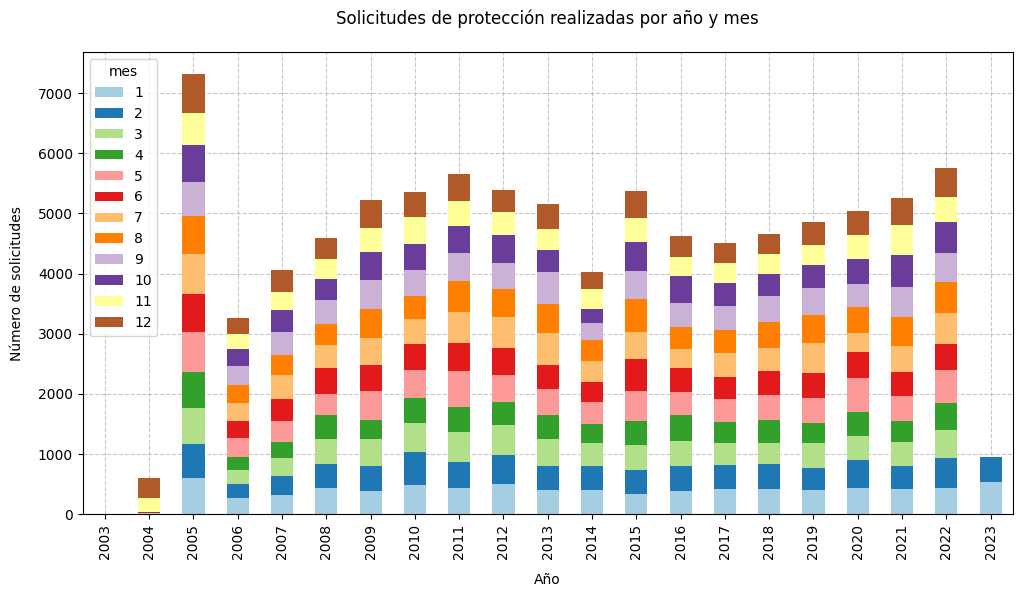

In [ ]:
data_grouped = new_df.groupby(['ano', 'mes']).size().unstack().fillna(0)
colores_meses = sns.color_palette("Paired", 12)
data_grouped.plot(kind='bar', stacked=True, figsize=(12, 6) , zorder=2 , color=colores_meses)
plt.grid(True, linestyle='--', alpha=0.7, zorder=0)
plt.xlabel('Año' , labelpad= 10)
plt.ylabel('Número de solicitudes' , labelpad= 10)
plt.title('Solicitudes de protección realizadas por año y mes' , pad=20)
#plt.savefig("Gráfico_barras_apiladas_año_mes.png", bbox_inches=('tight'))
plt.show()

- Con la línea plt.grid(True, linestyle='--', alpha=0.7), se habilita una cuadrícula punteada en el fondo del gráfico.
- .size() calcula el tamaño (cantidad de ocurrencias) de cada grupo resultante.
- .unstack() desagrupa los datos y coloca los meses como columnas y los años como índice, lo que crea una estructura de datos conveniente para crear el gráfico de barras apiladas.
- .plot(kind='bar') crea un gráfico de barras.
- stacked=True hace que las barras se apilen una sobre la otra en lugar de superponerse.
- figsize=(12, 6) establece el tamaño de la figura del gráfico en pulgadas (ancho x alto).
- plt.grid(True) habilita la cuadrícula en el gráfico.
- La función sns.color_palette("Paired", 12) se usa para obtener una paleta de colores basada la paleta Paired, con colores únicos correspondientes a los 12 meses.
---
- Con la gráfica se puede observar que no hay un mes que resalte especialmente a lo largo de los años, pero los años 2005, 2015 y 2022 tienen picos más altos; de la misma manera, los años 2006 y 2014 parecen ser los puntos más bajos, descartando los años 2003, 2004 y 2023 que son bajos porque no se tomaron los datos completos.
- Resulta interesante qe los años más bajos son directamente anteriores a los años más altos.
- También resalta que el año 2005 supera al año 2022, a pesar de que en este último se vivió la pandemia por Covid-19, en la que los casos de violencia intrafamiliar aumentaron significativamente.


## latitud

### Frecuencias absolutas y relativas

In [ ]:
freq_lati_new_df = new_df['latitud'].value_counts().reset_index()
freq_lati_new_df.columns = ['latitud', 'frecuencia_absoluta']
freq_lati_new_df['frecuencia_relativa'] = freq_lati_new_df['frecuencia_absoluta'] / len(new_df)
freq_lati_new_df

,latitud,frecuencia_absoluta,frecuencia_relativa
0,0.00,24498,0.267163
1,6.29,9766,0.106503
2,6.28,8634,0.094158
3,6.25,7206,0.078585
4,6.30,7107,0.077505
5,6.23,6136,0.066916
6,6.27,5913,0.064484
7,6.26,5779,0.063023
8,6.24,5149,0.056152
9,6.22,2672,0.029139


- Se observa que después de la limpieza, solo aparecen 33 datos en la tabla de frecuencias.
- El dato más repetido (0.00) corresponde a datos faltantes o datos mal tomados, así que el 26% de la información no aporta mucho al análisis.
- El siguiente dato más repetido (6.29) representa el 10,6%, cosa que es importante relacionar con la columna longitud para tener la localización más repetida.

### Medidas de tendencia central

In [ ]:
# Calcular la media
media_latitud = new_df['latitud'].mean()

# Calcular la mediana
mediana_latitud = new_df['latitud'].median()

# Calcular la moda
moda_latitud = new_df['latitud'].mode().values[0]

# Calcular sin el dato 0.0
latitudes_filtradas = new_df['latitud'][new_df['latitud'] != 0.00]
moda_latitud_fil = latitudes_filtradas.mode().values[0]
media_latitud_fil = latitudes_filtradas.mean()
mediana_latitud_fil = latitudes_filtradas.median()

# Imprimir los resultados
print("Media latitud:", media_latitud)
print("Mediana latitud:", mediana_latitud)
print("Moda latitud:", moda_latitud)
print("Media latitud sin 0.00:", moda_latitud_fil)
print("Media latitud sin 0.00:", media_latitud_fil)
print("Media latitud sin 0.00:", mediana_latitud_fil)

Media latitud: 4.492901621645202
Mediana latitud: 6.25
Moda latitud: 0.0
Media latitud sin 0.00: 6.29
Media latitud sin 0.00: 6.130829327817378
Media latitud sin 0.00: 6.27


- La media de la latitud, que incluye valores de 0.0, es de aproximadamente 4.49. Esto indica que, en promedio, las latitudes de los datos están alrededor de 4.49. Excluyendo valores de 0.0, es de 6.29.
- La moda de la latitud es 0.0, lo que indica que el valor 0.0 es el que más veces se repite en los datos. Sin ese dato, la moda de la latitudes de aproximadamente 6.27; esto sugiere que, cuando se excluyen los valores de 0.0, el dato repetido es un poco más alto.
- La mediana de la latitud, incluyendo los valores de 0.0, es de 6.25, pero sin ellos es de 6.13. AL ver esto, resalta que es el dato que menos cambia al respecto de si se incluyen o no los datos.


### Medidas de dispersión

In [ ]:
#Rango
rango_latitud = new_df['latitud'].max() - new_df['latitud'].min()

#Varianza
varianza_latitud = new_df['latitud'].var()

#Desviación estándar
desviacion_estandar_latitud = new_df['latitud'].std()

#Rango intercuartil
q1 = new_df['latitud'].quantile(0.25)
q3 = new_df['latitud'].quantile(0.75)
iqr = q3 - q1

#Coeficiente de variación
coeficiente_variacion_latitud = (desviacion_estandar_latitud / media_latitud) * 100

#Calcular excluyendo el 0.00
rango_latitud_fil = latitudes_filtradas.max() - latitudes_filtradas.min()
varianza_latitud_fil = latitudes_filtradas.var()
desviacion_estandar_latitud_fil = latitudes_filtradas.std()
coeficiente_variacion_latitud_fil = (desviacion_estandar_latitud_fil / media_latitud_fil) * 100

print("Rango latitud:", rango_latitud)
print("Varianza latitud:", varianza_latitud)
print("Desviación estándar latitud:", desviacion_estandar_latitud)
print("Coeficiente de variación latitud:", coeficiente_variacion_latitud)
print("Rango latitud sin 0.00:", rango_latitud_fil)
print("Varianza latitud sin 0.00:", varianza_latitud_fil)
print("Desviación estándar sin 0.00:", desviacion_estandar_latitud_fil)
print("Coeficiente de variación latitud si 0.00:", coeficiente_variacion_latitud_fil)

Rango latitud: 82.03
Varianza latitud: 14.844936968521296
Desviación estándar latitud: 3.8529127901525744
Coeficiente de variación latitud: 85.75555653367995
Rango latitud sin 0.00: 82.03
Varianza latitud sin 0.00: 10.214868172885511
Desviación estándar sin 0.00: 3.1960707396560406
Coeficiente de variación latitud si 0.00: 52.13113216436358


Con 0.00
- El rango de latitud es de 82.03 grados. Esto representa la diferencia entre la latitud máxima y la latitud mínima en los datos.
- La varianza de latitud es de aproximadamente 14.84. Esto indica que hay una dispersión moderada de los valores de latitud alrededor de la media.
- La desviación estándar de latitud es de aproximadamente 3.85, lo que muestra cuánto se alejan los valores de latitud de la media. En este caso, la desviación estándar es relativamente alta en comparación con la media, lo que sugiere una variabilidad considerable.
- El coeficiente de variación es muy alto, aproximadamente 85.76. Esto indica una gran variabilidad en las latitudes en relación con la media, lo que sugiere una amplia dispersión.
Todo esto se hace considerando que es un tipo de dato que incluye valores tanto positivos como negativos, así que la escala numérica es muy amplia.

Sin valores de 0.0:
- El rango de latitud, excluyendo los valores de 0.0, sigue siendo de 82.03 grados, lo que significa que la diferencia entre la latitud máxima y la latitud mínima se mantiene igual.
- La varianza de latitud, excluyendo los valores de 0.0, disminuye a aproximadamente 10.21. Esto indica una dispersión moderada de los valores de latitud sin incluir los 0.0.
- La desviación estándar de latitud, excluyendo los valores de 0.0, es de aproximadamente 3.20, lo que muestra que la dispersión moderada no cambia tanto.
- El coeficiente de variación, excluyendo los valores de 0.0, disminuye significativamente a aproximadamente 52.13. Esto indica una variabilidad menor en las latitudes sin incluir los valores de 0.0 en relación con la media.

### Gráficos

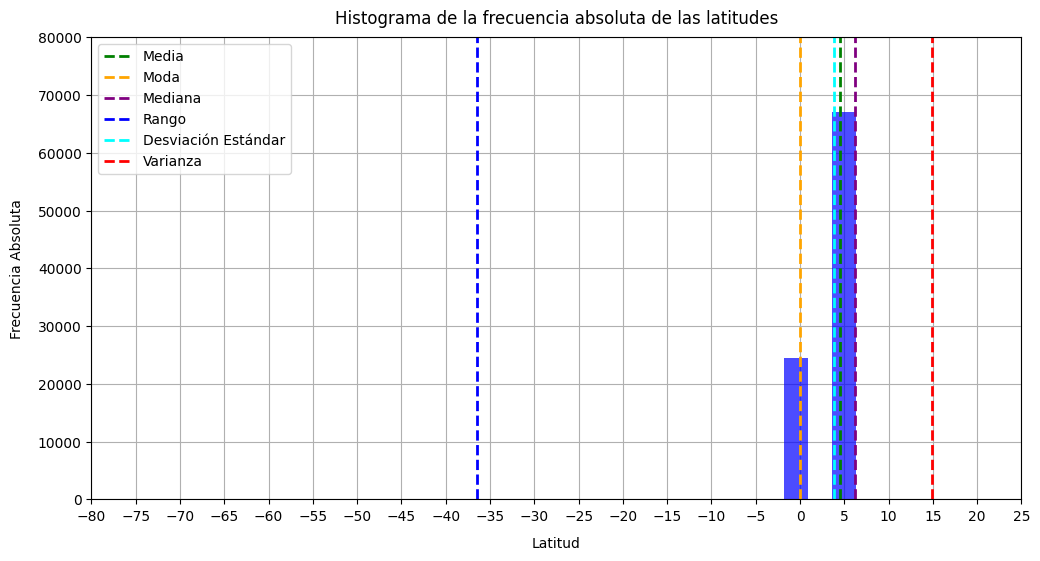

In [ ]:
latitudes = new_df['latitud']
bins = range(-80, 50, 30)
plt.figure(figsize=(12, 6))
plt.hist(latitudes, bins=30, color='blue', alpha=0.7, zorder=2)
plt.xlabel('Latitud', labelpad=10)
plt.ylabel('Frecuencia Absoluta', labelpad=10)
plt.title('Histograma de la frecuencia absoluta de las latitudes', pad=10)
plt.yticks(range(0, 80001, 10000))
plt.xticks(range(-80, 30, 5))
plt.axvline(media_latitud, color='green', linestyle='dashed', linewidth=2, label='Media')
plt.axvline(moda_latitud, color='orange', linestyle='dashed', linewidth=2, label='Moda')
plt.axvline(mediana_latitud, color='purple', linestyle='dashed', linewidth=2, label='Mediana')
plt.axvline(media_latitud - rango_latitud/2, color='blue', linestyle='dashed', linewidth=2, label='Rango')
plt.axvline(desviacion_estandar_latitud, color='cyan', linestyle='dashed', linewidth=2, label='Desviación Estándar')
plt.axvline(varianza_latitud, color='red', linestyle='dashed', linewidth=2, label='Varianza')
plt.legend()
plt.grid(True)
#plt.savefig("Histograma_latitud.png", bbox_inches=('tight'))
plt.show()

- Con bins = range(-80, 50, 30) se define una lista de valores llamada bins que especifica los límites de los intervalos en los que se agruparán las latitudes en el histograma.
- Con plt.hist(latitudes, bins=30, color='blue', alpha=0.7, zorder=2) se crea el histograma de las latitudes utilizando los datos de latitudes en los intervalos definidos por bins.
- Con plt.yticks(range(0, 80001, 10000)) se definen las marcas en el eje y en intervalos de 10,000, desde 0 hasta 80,000. Al tiempo, plt.xticks(range(-80, 30, 5)) define las marcas en el eje x en intervalos de 5 unidades desde -80 hasta 30.
---
- De la gráfica se deduce que el rango podría no ser un medida indicativa al respecto de los datos, mientras que las otras medidas se relacionan más directamente con lo que iluestra el histograma.
- Además, en el histograma solo resaltan dos barras, respondiendo a que hay una gran cantidad de datos 0.00, y la gran mayoría de datos distintos a 0.00 va de 4.5 o 6.5.



## longitud

### Frecuencias absolutas y relativas

In [ ]:
freq_long_new_df = new_df['longitud'].value_counts().reset_index()
freq_long_new_df.columns = ['longitud', 'frecuencia_absoluta']
freq_long_new_df['frecuencia_relativa'] = freq_long_new_df['frecuencia_absoluta'] / len(new_df)
freq_long_new_df

,longitud,frecuencia_absoluta,frecuencia_relativa
0,0.00,24500,0.267184
1,-75.55,12369,0.134890
2,-75.56,9794,0.106808
3,-75.58,6723,0.073318
4,-75.54,6467,0.070526
5,-75.59,5915,0.064506
6,-75.57,5873,0.064048
7,-75.60,5280,0.057581
8,-75.61,5094,0.055553
9,-75.62,3339,0.036413


- Se observa que después de la limpieza, solo aparecen 36 datos en la tabla de frecuencias.
- El dato más repetido (0.00) corresponde a datos faltantes o datos mal tomados, así que el 26,7% de la información no aporta mucho al análisis.
- El siguiente dato más repetido (-75.55) representa el 13,4%.
- Al relacionarlo con la latitud, el punto más repetido es (6.29 , -75.55), lo que equivale a Moscú Nº2, un barrio en la comuna 1 de Medellín.

### Medidas de tendencia central

In [ ]:
# Calcular la media
media_longitud = new_df['longitud'].mean()

# Calcular la mediana
mediana_longitud = new_df['longitud'].median()

# Calcular la moda
moda_longitud = new_df['longitud'].mode().values[0]

# Calcular sin el dato 0.0
longitudes_filtradas = new_df['longitud'][new_df['longitud'] != 0.00]
moda_longitud_fil = longitudes_filtradas.mode().values[0]
media_longitud_fil = longitudes_filtradas.mean()
mediana_longitud_fil = longitudes_filtradas.median()

# Imprimir los resultados
print("Media longitud:", media_longitud)
print("Mediana longitud:", mediana_longitud)
print("Moda longitud:", moda_longitud)
print("Moda longitud sin 0.00:", moda_longitud_fil)
print("Media longitud sin 0.00:", media_longitud_fil)
print("Mediana longitud sin 0.00:", mediana_longitud_fil)

Media longitud: -55.29660316040873
Mediana longitud: -75.56
Moda longitud: 0.0
Moda longitud sin 0.00: -75.55
Media longitud sin 0.00: -75.45772311263894
Mediana longitud sin 0.00: -75.57


Incluyendo 0.0:
- La media de la longitud es de aproximadamente -55.30; esto indica que, en promedio, las longitudes de los datos están alrededor de -55.30.
- La mediana de la longitud es de -75.56; por lo que, la mitad de los datos están por encima de -75.56 y la otra mitad está por debajo.
- La moda, al igual que en la columna anterior, es de 0.00.

Sin valores de 0.0:
- Tanto la moda, la media y la mediana, al excluir el dato 0.00, se ubiban alrededor de -75.5.

### Medidas de dispersión

In [ ]:
#Rango
rango_longitud = new_df['longitud'].max() - new_df['longitud'].min()

#Varianza
varianza_longitud = new_df['longitud'].var()

#Desviación estándar
desviacion_estandar_longitud = new_df['longitud'].std()

#Rango intercuartil
q1 = new_df['longitud'].quantile(0.25)
q3 = new_df['longitud'].quantile(0.75)
iqr = q3 - q1

#Coeficiente de variación
coeficiente_variacion_longitud = (desviacion_estandar_longitud / media_longitud) * 100

print("Rango longitud:", rango_longitud)
print("Varianza longitud:", varianza_longitud)
print("Desviación estándar longitud:", desviacion_estandar_longitud)
print("Coeficiente de variación longitud:", coeficiente_variacion_longitud)

Rango longitud: 89.38
Varianza longitud: 1122.315551724747
Desviación estándar longitud: 33.50097836966477
Coeficiente de variación longitud: -60.5841524704194


- El rango de longitud es de 89.38 grados. Es mayor que el dato en latitud.
- La varianza de longitud es de aproximadamente 1122.32. Esto indica que hay una dispersión considerable de los valores de longitud alrededor de la media.
- La desviación estándar de longitud es de aproximadamente 33.50, lo que muestra que la desviación estándar es relativamente alta en comparación con la media, lo que sugiere una variabilidad considerable.
- El coeficiente de variación es negativo, aproximadamente -60.58. En este caso es gracias a que la mayoría de los datos son negativos.






### Gráficos

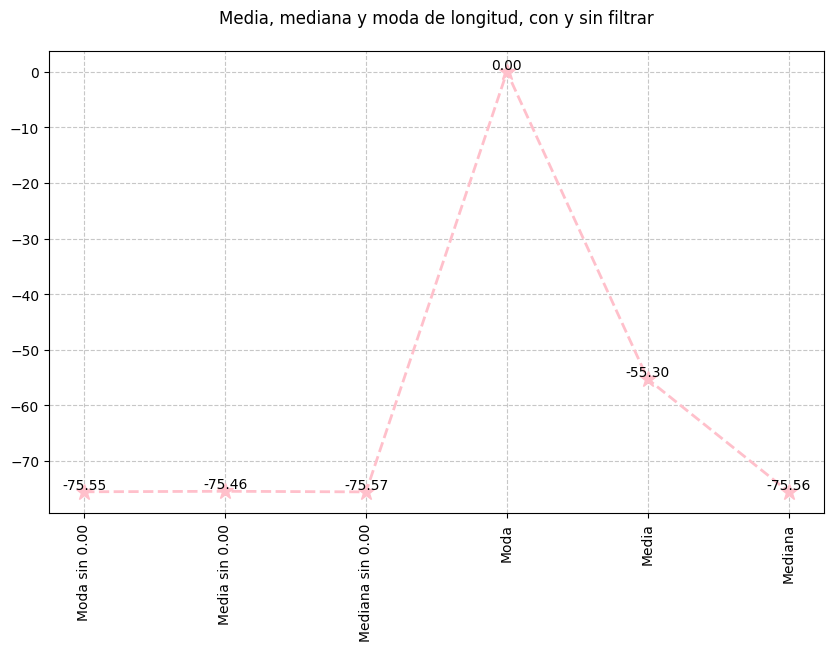

In [ ]:
longitudes_filtradas = new_df['longitud'][new_df['longitud'] != 0.00]
moda_longitud_fil = longitudes_filtradas.mode().values[0]
media_longitud_fil = longitudes_filtradas.mean()
mediana_longitud_fil = longitudes_filtradas.median()
etiquetas = ['Moda sin 0.00', 'Media sin 0.00', 'Mediana sin 0.00', 'Moda', 'Media', 'Mediana']
valores = [moda_longitud_fil, media_longitud_fil, mediana_longitud_fil, moda_longitud, media_longitud, mediana_longitud]
plt.figure(figsize=(10, 6))
plt.plot(etiquetas, valores, marker='*', linestyle='--', color='pink', linewidth=2, markersize=12)
plt.title('Media, mediana y moda de longitud, con y sin filtrar', pad=20)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=90)
for i in range(len(etiquetas)):
    plt.text(etiquetas[i], valores[i], f'{valores[i]:.2f}', ha='center', va='bottom')
#plt.savefig("Gráfico_linea_longitud.png", bbox_inches=('tight'))
plt.show()

- El código longitudes_filtradas = new_df['longitud'][new_df['longitud'] != 0.00], crea una serie de pandas llamada longitudes_filtradas que contiene solo las longitudes que no son igual a 0.00, es decir, se filtran los valores iguales a cero.
- Con plt.plot(etiquetas, valores, marker='*', linestyle='--', color='pink', linewidth=2, markersize=12), se crea el gráfico de líneas que conecta los valores en etiquetas y valores. Se utilizan asteriscos como marcadores, un estilo de línea discontinua ('--'), el color rosa ('pink'), un ancho de línea de 2 unidades y un tamaño de marcador de 12.
- El bucle for se utiliza para agregar valores numéricos en el gráfico, junto con las etiquetas, para mostrar los valores exactos en las ubicaciones correspondientes en el gráfico.
---
- La gráfica ilustra las medidas de tendencia central considerando y sin considerar el dato 0.00. Por ello, se puede ver que cuando se excluye, los datos son mucho mas consistentes y uniformes; cuando se incluye, los datos varian mucho más, a excepción de la mediana (sugiere que los datos 0.00 están distribuidos igualitariamente a lo largo de la columna).



## edad

### Frecuencias absoluta y relativa

In [ ]:
freq_unit_new_df = new_df['edad'].value_counts().reset_index()
freq_unit_new_df.columns = ['edad', 'frecuencia_absoluta']
freq_unit_new_df['frecuencia_relativa'] = freq_unit_new_df['frecuencia_absoluta'] / len(new_df)
freq_unit_new_df

,edad,frecuencia_absoluta,frecuencia_relativa
0,30,2502,0.027286
1,27,2457,0.026795
2,28,2377,0.025922
3,25,2361,0.025748
4,29,2348,0.025606
...,...,...,...
98,99,6,0.000065
99,97,6,0.000065
100,100,4,0.000044
101,102,1,0.000011


- Aparecen 102 edades, ninguna con una repetición especialmete alta.
- Apróximadamente, se puede ver que entre los 20 y los 30 años están los datos que más se repiten. Y entre los 92 y los 102, los que menos se repiten.
- Es posible ver que se tienen datos que van desde el dato -1, el cual se considera un dato confuso pues no es coherente (al menos de que se refiera a que es menor del año, pero la información es limitada y no permite tener certeza sobre esta conclusión).

### Medidas de tendencia central

In [ ]:
# Calcular la media
media_edad = new_df['edad'].mean()

# Calcular la mediana
mediana_edad= new_df['edad'].median()

# Calcular la moda
moda_edad = new_df['edad'].mode().values[0]

# Imprimir los resultados
print("Media edad:", media_edad)
print("Mediana edad:", mediana_edad)
print("Moda edad:", moda_edad)

Media edad: 38.2818958090232
Mediana edad: 36.0
Moda edad: 30


- La media de la edad es de aproximadamente 38.28 años. Esto significa que, en promedio, la edad de las víctimas es de 38 años.
- La mediana de la edad es de 36.0 años. Esto indica que la mitad de las personas en el conjunto de datos tienen 36 años o menos, y la otra mitad tiene 36 años o más.
- La moda de la edad es 30 años, lo que significa que el valor de 30 es el que más veces se repite en el conjunto de datos.

### Medidas de dispersión

In [ ]:
#Rango
rango_edad = new_df['edad'].max() - new_df['edad'].min()

#Varianza
varianza_edad = new_df['edad'].var()

#Desviación estándar
desviacion_estandar_edad = new_df['edad'].std()

#Rango intercuartil
q1 = new_df['edad'].quantile(0.25)
q3 = new_df['edad'].quantile(0.75)
iqr = q3 - q1

#Coeficiente de variación
coeficiente_variacion_edad = (desviacion_estandar_edad / media_edad) * 100

print("Rango edad:", rango_edad)
print("Varianza edad:", varianza_edad)
print("Desviación estándar edad:", desviacion_estandar_edad)
print("Coeficiente de variación edad:", coeficiente_variacion_edad)

Rango edad: 103
Varianza edad: 285.68810280963794
Desviación estándar edad: 16.902310576061428
Coeficiente de variación edad: 44.15222971292212


- El rango de edad es de 103 años. Esto representa la diferencia entre la edad máxima y la edad mínima en el conjunto de datos, sugiriendo que la escala de edades esmuy amplia.
- La varianza de edad es de aproximadamente 285.69. Esto indica que hay una dispersión considerable de las edades alrededor de la media.
- La desviación estándar de edad es de aproximadamente 16.90, lo que muestra que la desviación estándar es relativamente alta en comparación con la media, lo que sugiere una variabilidad considerable.
- El coeficiente de variación es aproximadamente 44.15. Este valor indica que la variabilidad en las edades es alta en relación con la media.

### Gráficos

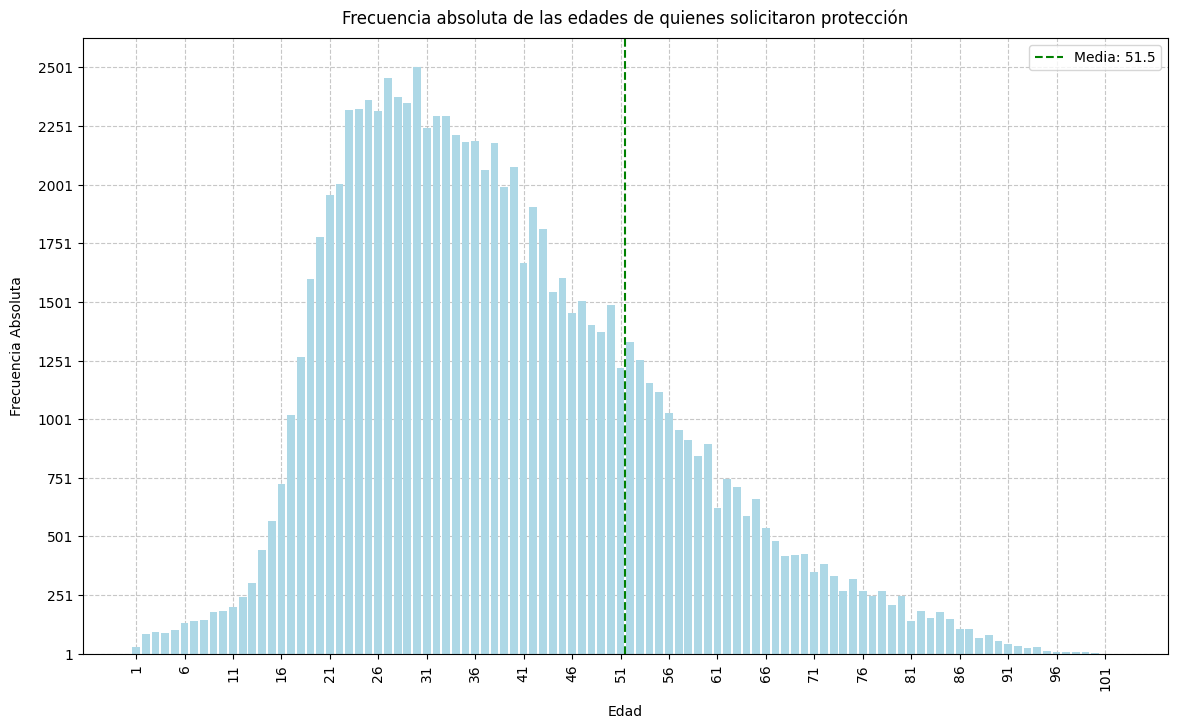

In [ ]:
filtered_df = freq_unit_new_df[freq_unit_new_df['edad'] != -1]
plt.figure(figsize=(14, 8))
plt.bar(filtered_df['edad'], filtered_df['frecuencia_absoluta'], color='lightblue' , zorder=2)
plt.title('Frecuencia absoluta de las edades de quienes solicitaron protección', pad=10)
plt.xlabel('Edad', labelpad=10)
plt.ylabel('Frecuencia Absoluta', labelpad=10)
# Establecer los ticks personalizados en el eje x (cada 5 unidades)
custom_ticks = range(min(filtered_df['edad']), max(filtered_df['edad']) + 1, 5)
plt.xticks(custom_ticks, rotation=90)
custom_ticks = range(min(filtered_df['frecuencia_absoluta']), max(filtered_df['frecuencia_absoluta']) + 0, 250)
plt.yticks(custom_ticks)
media = filtered_df['edad'].mean()
plt.axvline(x=media, color='green', linestyle='--', label=f'Media: {media}')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7, zorder=0)
#plt.savefig("Gráfico_barras_edad_víctima.png", bbox_inches=('tight'))
plt.show()

- Con filtered_df se ha filtrado el DataFrame original freq_unit_new_df para excluir las filas donde el valor de la columna 'edad' sea igual a -1.
- "plt.bar(filtered_df['edad'], filtered_df['frecuencia_absoluta'], color='lightblue', zorder=2)": Esta línea crea un gráfico de barras utilizando los datos del DataFrame filtered_df. Las edades se representan en el eje x y las frecuencias absolutas en el eje y. El color de las barras se establece en 'lightblue', y el parámetro zorder controla el orden en el que se dibujan los elementos en el gráfico.
- Con custom_ticks se definen ticks personalizados en los ejes x e y para mejorar la legibilidad del gráfico. En el eje x, los ticks se establecen en incrementos de 5 unidades, y en el eje y, se establecen en incrementos de 250 unidades.
- En la línea "plt.axvline(x=moda, color='red', linestyle='--', label=f'Moda: {moda}')", se dibuja una línea vertical en el gráfico en la posición de la moda.
---
- Para el gráfico, se ha eliminado el dato -1 porque no hay información concluyente sobre a qué hace referencia dicho dato.
- Se ve que claramente hay una subida significativa de los casos entre las edades 11 y 30, mientras que hay un descenso constante entre los 30 y los 101.
- La media, al eliminar el dato -1, es cercana a los 50, lo cual tiene sentido en una escala donde las edades van de 1 a 101. Pero, este dato no se considera demasiado influyente, y la moda parece ser un mejor indicador.


## sexo_medico

### Frecuencias absolutas y relativas

In [ ]:
freq_sexo_new_df = new_df['sexo_medico'].value_counts().reset_index()
freq_sexo_new_df.columns = ['sexo_medico', 'frecuencia_absoluta']
freq_sexo_new_df['frecuencia_relativa'] = freq_sexo_new_df['frecuencia_absoluta'] / len(new_df)
freq_sexo_new_df

,sexo_medico,frecuencia_absoluta,frecuencia_relativa
0,Mujer,74783,0.815545
1,Hombre,14140,0.154204
2,Sin dato,2774,0.030252


### Gráficos

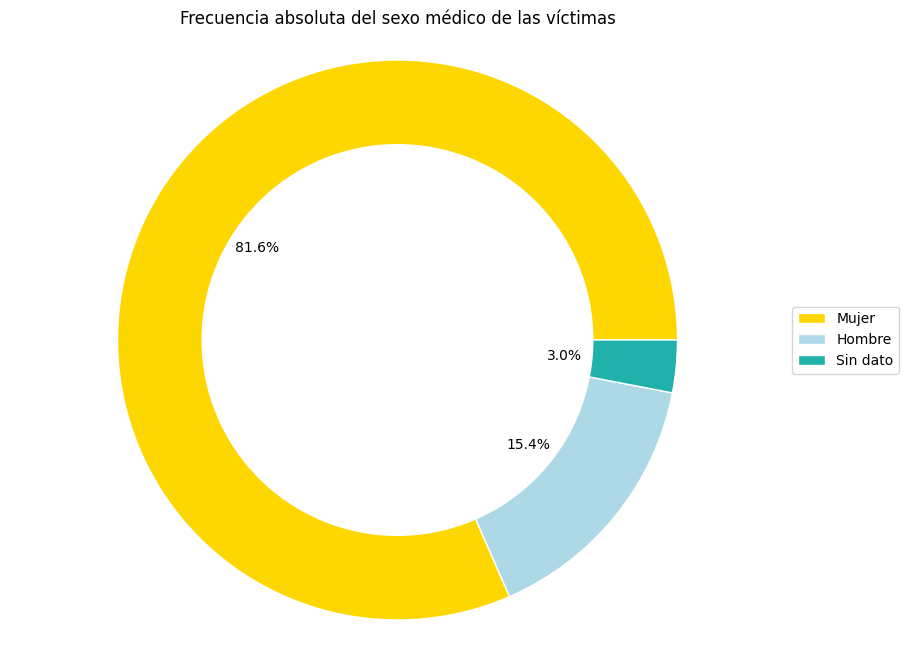

In [ ]:
sexo = freq_sexo_new_df['sexo_medico']
frecuencia_absoluta = freq_sexo_new_df['frecuencia_absoluta']
colores = ['gold' , 'lightblue' , 'lightseagreen']
plt.figure(figsize=(10, 8))
plt.pie(frecuencia_absoluta , autopct='%1.1f%%', startangle=360, wedgeprops={'edgecolor': 'white'} , colors=colores)
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title('Frecuencia absoluta del sexo médico de las víctimas')
legend_labels = sexo
plt.legend(legend_labels, loc='center left', bbox_to_anchor=(1, 0.5))
plt.axis('equal')
#plt.savefig("grafico_dona_sexo_death.png", bbox_inches=('tight'))
plt.show()

- Se busca definir una lista de colores, por ello se indica que colores = ['gold', 'lightblue', 'lightseagreen'].
- Con plt.pie(frecuencia_absoluta, autopct='%1.1f%%', startangle=360, wedgeprops={'edgecolor': 'white'}, colors=colores), se crea el gráfico de pastel con los datos de frecuencia_absoluta. El argumento autopct muestra el porcentaje en cada segmento del gráfico, el startangle establece el ángulo inicial a 360 grados (arriba), wedgeprops configura el color del borde de cada segmento y colors establece los colores de los segmentos.
- En cambio, centre_circle = plt.Circle((0, 0), 0.70, fc='white'), crea un círculo blanco (un agujero en el gráfico de pastel) para hacer un gráfico de donut. Se especifica el centro y el radio del círculo.
---
- Al tener pocos datos, y al tener estos un gran significado, este gráfico iluestra eficientemente la distribución de casos según el sexo médico.
- Se puedever la predominancia que tiene el ser mujer en los casos en donde fue solicitada una medida de protección ante un caso de violencia intrafamiliar.





## estado_civil

### Frecuencias absolutas y relativas

In [ ]:
freq_estado_new_df = new_df['estado_civil'].value_counts().reset_index()
freq_estado_new_df.columns = ['estado_civil', 'frecuencia_absoluta']
freq_estado_new_df['frecuencia_relativa'] = freq_estado_new_df['frecuencia_absoluta'] / len(new_df)
freq_estado_new_df

,estado_civil,frecuencia_absoluta,frecuencia_relativa
0,Soltero(a),33916,0.369870
1,Casado(a),24613,0.268417
2,Unión marital de hecho,23038,0.251240
3,Viudo(a),3888,0.042401
4,Sin dato,3319,0.036195
5,Divorciado(a),2923,0.031877


- Con la tabla se ve que los datos son consistentes y coherentes.
- Del mismo modo, se puede observar que la mayoría de incidentes se dieron con víctimas solteras, pero el 26,8% corresponde a personas casadas y el 25,1% a personas en una unión marital de hecho; esto, sugiere que se dan más casos con víctimas que tienen parejas en el momento del hecho, que con víctimas solteras.


### Gráficos

<ipython-input-43-6a215d374ea6>:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colormap = plt.cm.get_cmap('Blues')


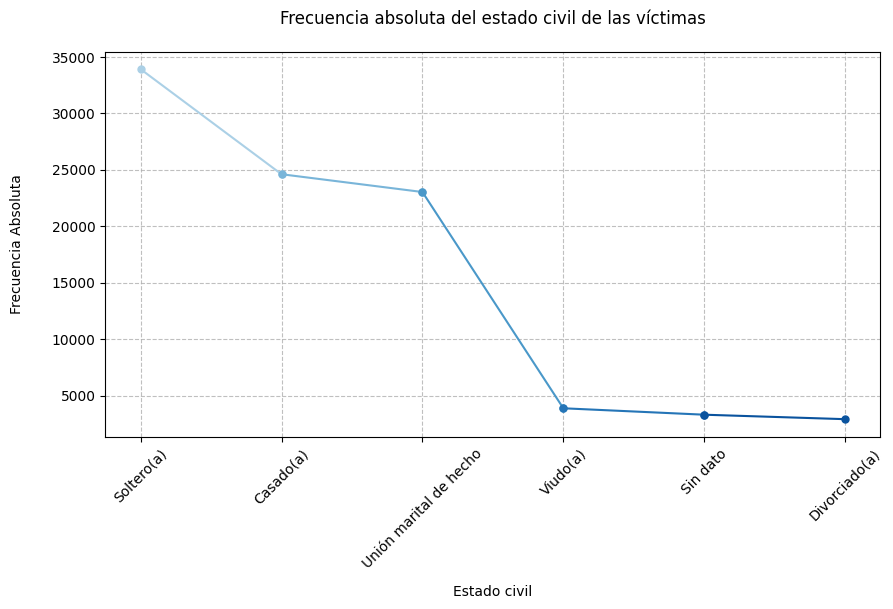

In [ ]:
estado=freq_estado_new_df['estado_civil']
frecuencia = freq_estado_new_df['frecuencia_absoluta']
colormap = plt.cm.get_cmap('Blues')
norm = mcolors.Normalize(vmin=-0.5, vmax=1)
fig, ax = plt.subplots(figsize=(10, 5))
for i in range(len(estado) - 1):
    color = colormap(norm(i / (len(estado) - 1)))
    ax.plot([estado[i], estado[i + 1]], [frecuencia[i], frecuencia[i + 1]], color=color, marker='o', markersize=5)
ax.set_xlabel('Estado civil', labelpad=10)
ax.set_ylabel('Frecuencia Absoluta' , labelpad=20)
ax.set_title('Frecuencia absoluta del estado civil de las víctimas' , pad=20)
plt.xticks(rotation=45)
ax.grid(True, linestyle='dashed', alpha=0.8)
#plt.savefig("grafico_linea_edtado_civil.png", bbox_inches=('tight'))
plt.show()

- colormap = plt.cm.get_cmap('Blues'): Se define un mapa de colores basado en el esquema de colores 'Blues' de matplotlib.
- norm = mcolors.Normalize(vmin=-0.5, vmax=1): Se crea una normalización de colores que se utilizará para asignar colores a los segmentos del gráfico de líneas.
- fig, ax = plt.subplots(figsize=(10, 5)): Se crea una figura y un objeto de eje (ax) de matplotlib con un tamaño de 10 pulgadas de ancho y 5 pulgadas de alto para el gráfico de líneas.
- El bucle for itera a través de los datos de estado civil y frecuencia. Dentro del bucle, se asigna un color a cada segmento del gráfico de líneas en función de la normalización y se utilizan marcadores ('o') en los puntos de datos.
---
- Con la gráfica es posible ver que hay una gran diferencia entres los 3 datos principales, y los 3 datos restantes. Por ello, el foco de atención debe centrarse en personas con pareja (en el presente), y personas solteras que no estén previamente divorciadas.




## lugar

### Frecuencias absolutas y relativas

In [ ]:
freq_lugar_new_df = new_df['lugar'].value_counts().reset_index()
freq_lugar_new_df.columns = ['lugar', 'frecuencia_absoluta']
freq_lugar_new_df['frecuencia_relativa'] = freq_lugar_new_df['frecuencia_absoluta'] / len(new_df)
freq_lugar_new_df

,lugar,frecuencia_absoluta,frecuencia_relativa
0,Residencia,72848,0.794443
1,Sin dato,13568,0.147966
2,Vía pública,3310,0.036097
3,Almacén tienda y otro,945,0.010306
4,Puesto de trabajo,586,0.006391
5,Parque,322,0.003512
6,"Institución educativa (jardín, primaria o secu...",102,0.001112
7,Zona despoblada,16,0.000174


- De nuevo, los datos son consistentes y son entendibles.
- Con la tabla se puede observar que la gran mayoría de incidentes en los que se solicitó una medida de protección, sucedieron al interior de los hogares. Esto tiene más sentido cuando se compara con el dato del estado civil de las víctimas, pues resalta que muchos casos se dieron dentro de la residencia con peronas en una relación; lo que sugiere que hay una probabilidad de que sean las parejas quienes cometan el acto de violencia intrafamiliar.

### Gráficos

<ipython-input-45-3e47847e1cab>:9: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  plt.legend(legend_labels, loc='center left', bbox_to_anchor=(1, 0.5), title="Lugar", labels=[f'{l}: {f/sum(frecuencia_absoluta)*100:.1f}%' for l, f in zip(lugar, frecuencia_absoluta)])


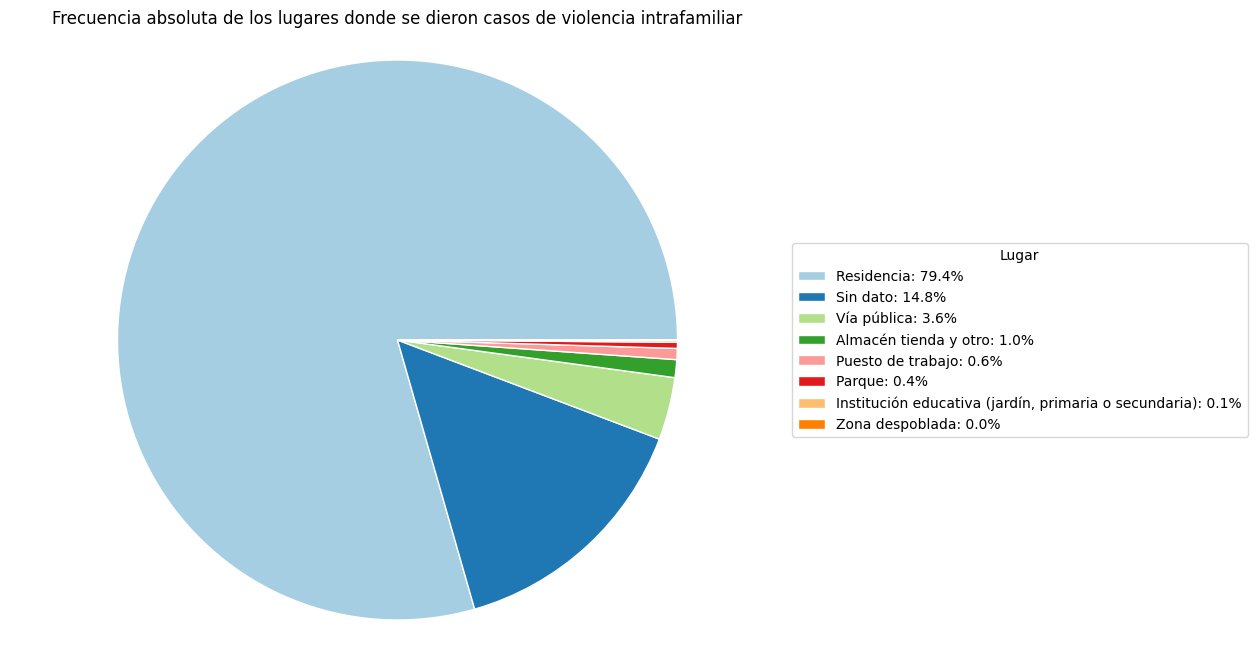

In [ ]:
lugar = freq_lugar_new_df['lugar']
frecuencia_absoluta = freq_lugar_new_df['frecuencia_absoluta']
colores = plt.cm.Paired(range(len(lugar)))
plt.figure(figsize=(10, 8))
plt.pie(frecuencia_absoluta, labels=None, autopct=None, startangle=360, wedgeprops={'edgecolor': 'white'}, colors=colores)
fig = plt.gcf()
plt.title('Frecuencia absoluta de los lugares donde se dieron casos de violencia intrafamiliar')
legend_labels = lugar
plt.legend(legend_labels, loc='center left', bbox_to_anchor=(1, 0.5), title="Lugar", labels=[f'{l}: {f/sum(frecuencia_absoluta)*100:.1f}%' for l, f in zip(lugar, frecuencia_absoluta)])
plt.axis('equal')
#plt.savefig("grafico_circular_lugar.png", bbox_inches=('tight'))
plt.show()

- Al usar colores = plt.cm.Paired(range(len(lugar))), se está generando una lista de colores utilizando una paleta de colores llamada 'Paired' proporcionada por Matplotlib. La cantidad de colores generados es igual a la longitud de la variable lugar, que corresponde al número de lugares diferentes.
- Con plt.pie(frecuencia_absoluta, labels=None, autopct=None, startangle=360, wedgeprops={'edgecolor': 'white'}, colors=colores), se crea un gráfico circular (gráfico de pastel) utilizando la frecuencia absoluta de los casos de violencia intrafamiliar.
- plt.legend(legend_labels, loc='center left', bbox_to_anchor=(1, 0.5), title="Lugar", labels=[f'{l}: {f/sum(frecuencia_absoluta)*100:.1f}%' for l, f in zip(lugar, frecuencia_absoluta)]), agrega una leyenda al gráfico en la posición 'center left' y se coloca fuera del gráfico utilizando bbox_to_anchor. Las etiquetas de la leyenda se crean mediante una comprensión de lista que incluye el nombre del lugar y el porcentaje de casos que representa con respecto al total.
---
- Con la gráfica se observa lo que ya se ha descrito, pero también es posible ver que, además de sin dato, los siguientes datos en orden (vía pública y almacen tienda) corresponder a lugares públicos. Es decir, la violencia intrafamiliar no se restringe a la residencia como espacio privado.


## sede_receptora

### Frecuencias absolutas y relativas

In [ ]:
freq_sector_new_df = new_df['sede_receptora'].value_counts().reset_index()
freq_sector_new_df.columns = ['sede_receptora', 'frecuencia_absoluta']
freq_sector_new_df['frecuencia_relativa'] = freq_sector_new_df['frecuencia_absoluta'] / len(new_df)
freq_sector_new_df

,sede_receptora,frecuencia_absoluta,frecuencia_relativa
0,Comisaría 8 / Villa Hermosa,6768,0.073808
1,Comisaría 3 / Manrique,5757,0.062783
2,Comisaría 6 / 12 de Octubre,5664,0.061769
3,Comisaría 4 / Campo Valdés,5483,0.059795
4,Comisaría 13 / San Javier,5359,0.058442
...,...,...,...
63,Inspección 1 / V. Guadalupe,4,0.000044
64,Inspección 5 / Castilla,3,0.000033
65,Inspección 6a / 12 de Octubre,3,0.000033
66,Inspección 7b / Robledo el Diamante,3,0.000033


- Con la tabla se puede ver que la principales sedes que recibieron y atendieron las solicitudes de protección son las Comisarías, en tanto las que menos porcentaje del total representan son las Inspecciones.

### Gráfico

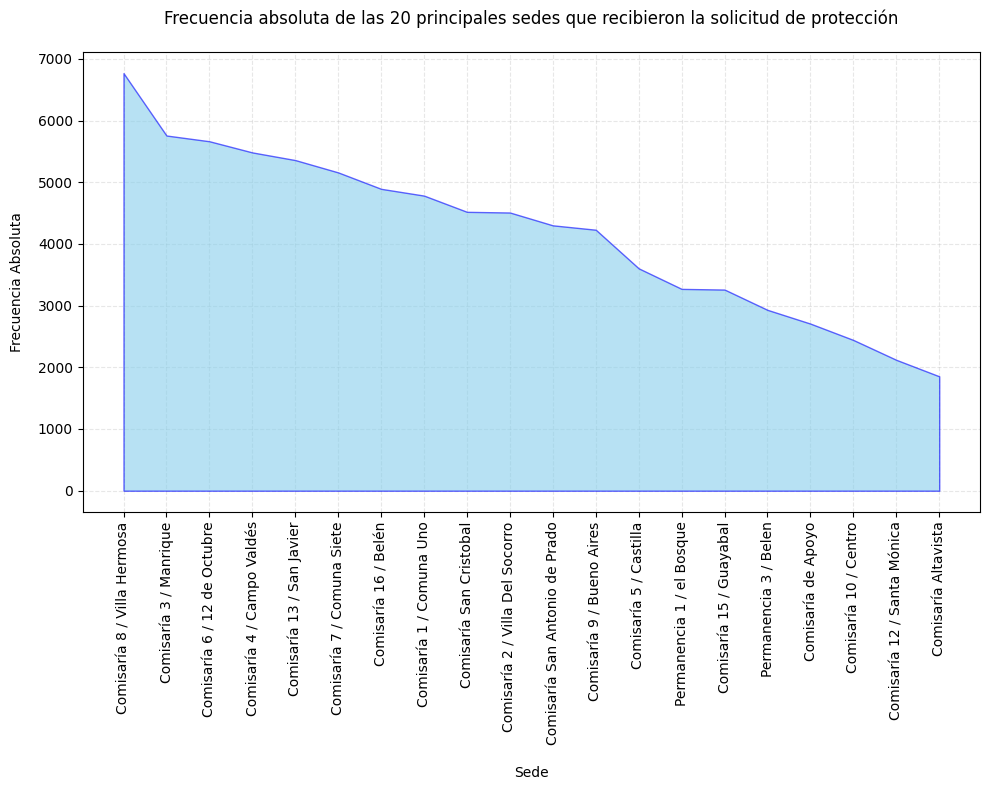

In [ ]:
freq_sector_new_df = freq_sector_new_df.sort_values(by='frecuencia_absoluta', ascending=False)
top_20 = freq_sector_new_df.head(20)

sede = top_20['sede_receptora']
frecuencia_absoluta = top_20['frecuencia_absoluta']

plt.figure(figsize=(10, 8))
plt.fill_between(sede, frecuencia_absoluta, color="skyblue", alpha=0.6, edgecolor="blue", zorder=2)
plt.xticks(rotation=90)
plt.xlabel('Sede', labelpad=15)
plt.ylabel('Frecuencia Absoluta', labelpad=10, zorder=1)
plt.title('Frecuencia absoluta de las 20 principales sedes que recibieron la solicitud de protección', pad=20)
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.3)
#plt.savefig("Gráfico_densidad_sedes_policía.png", bbox_inches=('tight'))
plt.show()

- Primero, se ordena el DataFrame freq_sector_new_df según la columna 'frecuencia_absoluta' en orden descendente, lo que coloca las sedes con las frecuencias más altas en la parte superior del DataFrame. Para ello se usa freq_sector_new_df = freq_sector_new_df.sort_values(by='frecuencia_absoluta', ascending=False).
- Luego, con top_20 = freq_sector_new_df.head(20), se seleccionan las 20 principales filas (sedes) del DataFrame ordenado, lo que representa las 20 sedes con las frecuencias más altas.
- Con plt.fill_between(sede, frecuencia_absoluta, color="skyblue", alpha=0.6, edgecolor="blue", zorder=2), se utiliza fill_between para crear el área que será rellenada. Los argumentos incluyen los datos de eje x (sedes), los datos de eje y (frecuencia_absoluta), el color de relleno (skyblue), la transparencia (alpha), el color del borde (blue) y el parámetro zorder para controlar la superposición de elementos en el gráfico.
---
- Se puede ver que, la mayoría de las sedes están ubicadas del centro al norte de Medellín. Muchas de ellas quedan en barrios o comunas con problemas de sociales notables, como mayores índices de pobreza, invasiones significativas y presencia de bandas.
- No obstante, se indica la sede que recibió la solicitud, lo que podría no ser directamente equivalente con la distribución geográfica de casos. Pero, se podría usar la columna para extraer estos datos, agrupando las comisarías y las inspecciones según la comuna en la que están ubicadas.

## Tabla bimodal y gráficos interrelacionados

Cin la tabla bimodal, se busca cruzar la información de dos columnas para relacionarla.

In [ ]:
tabla_bimodal = pd.crosstab(new_df['lugar'], new_df['sexo_medico'])
print(tabla_bimodal)

sexo_medico                                         Hombre  Mujer  Sin dato
lugar                                                                      
Almacén tienda y otro                                  202    743         0
Institución educativa (jardín, primaria o secun...      17     85         0
Parque                                                  51    271         0
Puesto de trabajo                                      158    428         0
Residencia                                           11372  61476         0
Sin dato                                              1768   9026      2774
Vía pública                                            571   2739         0
Zona despoblada                                          1     15         0


Como se puede ver, en todos lo lugares la densidad del sexo médico se inclina hacia las mujeres. Pero, resalta que en las residencias, en la vías públicas y el las instituciones educativas, los casos con víctimas mujeres superan 5 veces a los casos con víctimas hombres. Igualmente, en las zonas despobladas, de 16 casos, 15 correspondieron a víctimas mujeres.

In [ ]:
tabla_bimodal_ = pd.crosstab(new_df['fecha_hecho'], new_df['sexo_medico'])
print(tabla_bimodal_)

sexo_medico  Hombre  Mujer  Sin dato
fecha_hecho                         
2003-07-25        0      2         0
2003-12-01        0      0         1
2003-12-12        1      1         0
2003-12-21        0      1         0
2003-12-25        0      1         0
...             ...    ...       ...
2023-02-24        2     14         0
2023-02-25        0     17         0
2023-02-26        5     28         0
2023-02-27        3     13         0
2023-02-28        2     13         0

[6716 rows x 3 columns]


Con este cruce, se logra información muy específica pero muy extensa. Es preferible agrupar los datos de otra manera para permitir una mejor comparación.

In [ ]:
tabla_bimodal_mes = pd.crosstab(new_df['mes'], new_df['sexo_medico'])
print(tabla_bimodal_mes)

sexo_medico  Hombre  Mujer  Sin dato
mes                                 
1              1243   6510       275
2              1172   6510       224
3              1176   6081       261
4              1063   5571       253
5              1280   6454       279
6              1186   6231       242
7              1193   6444       192
8              1211   6529       165
9              1247   6441       133
10             1175   6206       164
11             1077   5639       281
12             1117   6167       305


- Con esta sub-categoría, la inromación es mucho más fácil de observar.
- Se puede ver que los meses en donde se dieron más casos involucrando a víctimas mujeres fue en agosto; mientras que, la mayoría de los casos que involucran a hombres fue en mayo. En cambio, el mes en  el que se presentaron menos casos, que coincide tanto para hombres como para mujeres, fue abril.
- No obstante, la cantidad de casos a lo largo de los meses no varia demasiado,

In [ ]:
tabla_bimodal_año = pd.crosstab(new_df['ano'], new_df['sexo_medico'])
print(tabla_bimodal_año)

sexo_medico  Hombre  Mujer  Sin dato
ano                                 
2003              1      5         1
2004             73    263       264
2005            919   4167      2230
2006            445   2538       279
2007            543   3515         0
2008            727   3870         0
2009            943   4283         0
2010            985   4366         0
2011            985   4673         0
2012            897   4499         0
2013            860   4289         0
2014            656   3368         0
2015            870   4508         0
2016            727   3905         0
2017            681   3833         0
2018            734   3929         0
2019            748   4117         0
2020            699   4348         0
2021            745   4511         0
2022            787   4969         0
2023            115    827         0


- Al analizar solo el año de los hechos, resalta que el 2022 fue el que más solicitudes de protección a mujeres registró, coincidiendo con la creciente violencia de género de la pandemia vivida. Para las solicitudes de hombres, entre el 2009 y 2011 hay una constante del punto más alto (más de 900 casos por año).
- En ambos casos, 2006 fue el año que menos casos presentó, sin considerar 2003, 2003 y 2023 por datos incompletos.
- Hay que observar que, hasta 2006 se tienen datos incompletos con el sin dato, pero tanto en 2004 como en 2005, hay un pico importante en proporción con la totalidad de los datos. Esto sugiere que después de 2005, la manera en la que se recolectó la infromación cambió.

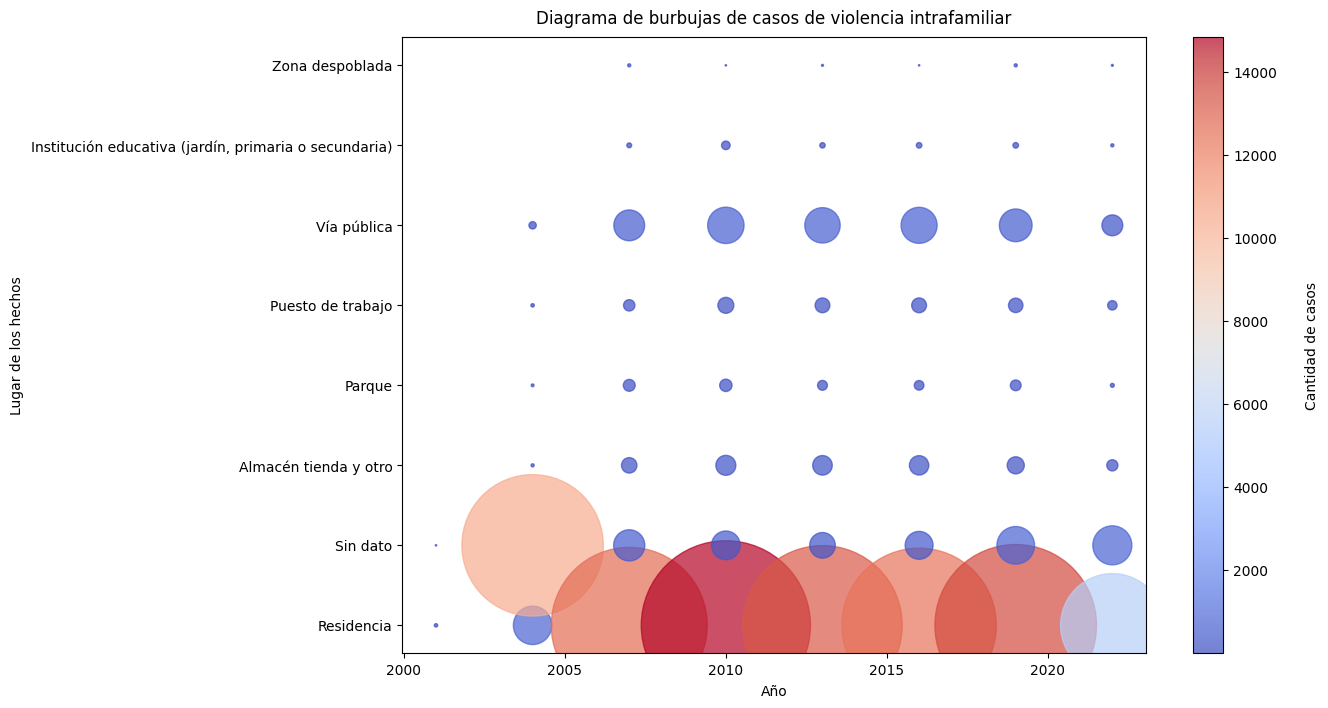

In [ ]:
bubble_data = new_df.copy()
bubble_data['ano_intervalo'] = (bubble_data['ano'] // 3) * 3
bubble_data = bubble_data.groupby(['ano_intervalo', 'lugar']).size().reset_index(name='cantidad')
plt.figure(figsize=(12, 8))
plt.scatter(bubble_data['ano_intervalo'], bubble_data['lugar'], s=bubble_data['cantidad'], c=bubble_data['cantidad'], cmap='coolwarm', alpha=0.7)
plt.title('Diagrama de burbujas de casos de violencia intrafamiliar', pad=10)
plt.xlabel('Año', labelpad=5)
plt.ylabel('Lugar de los hechos', labelpad=5)
cbar = plt.colorbar()
cbar.set_label('Cantidad de casos', labelpad=20)
plt.savefig("Diagrama_burbujas_lugar_año.png", bbox_inches=('tight'))
plt.show()

- Se incia con bubble_data = new_df.copy(), para crear una copia del DataFrame original new_df en una nueva variable llamada bubble_data.
- Al indicar bubble_data['ano_intervalo'] = (bubble_data['ano'] // 3) * 3, se calcula un nuevo atributo llamado 'ano_intervalo' que agrupa los años en intervalos de 3 años. Esto se logra dividiendo el año en el DataFrame original por 3 y luego multiplicando nuevamente por 3 para obtener el año más cercano que es múltiplo de 3. Esto permite agrupar los datos en intervalos de tres años. Aunque, por estética, no se van a modificar los labels de x, que tiene intervalos de cada 5 años.
- Con bubble_data = bubble_data.groupby(['ano_intervalo', 'lugar']).size().reset_index(name='cantidad'), se agrupan los datos en el DataFrame bubble_data por 'ano_intervalo' y 'lugar' y se calcula la cantidad de casos en cada grupo. El resultado se almacena en un nuevo DataFrame con tres columnas: 'ano_intervalo', 'lugar' y 'cantidad'.
- Se utiliza la función scatter para crear el diagrama de burbujas. Los argumentos incluyen los datos de los ejes x (años en intervalos), los datos de los ejes y (lugares), el tamaño de las burbujas (s), el color de las burbujas (c), el mapa de colores (cmap) y la transparencia (alpha). El tamaño y el color de las burbujas se basan en la cantidad de casos ('cantidad').
- cbar = plt.colorbar(), agrega una barra de color que muestra la escala de colores utilizada en el diagrama de burbujas.
---
- Se puede ver que el lugar principal donde se dan casos de violencia intrafamiliar que terminan en la solicitud de medidas de protección, es en las residencias. Y, apróximadamente, entre el 2007 y el 2013, se dio la mayor cantidad de casos en las residencias.


<ipython-input-118-558970fe54e2>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['grupo_edad'] = pd.cut(new_df['edad'], bins=edad_bins, right=False)


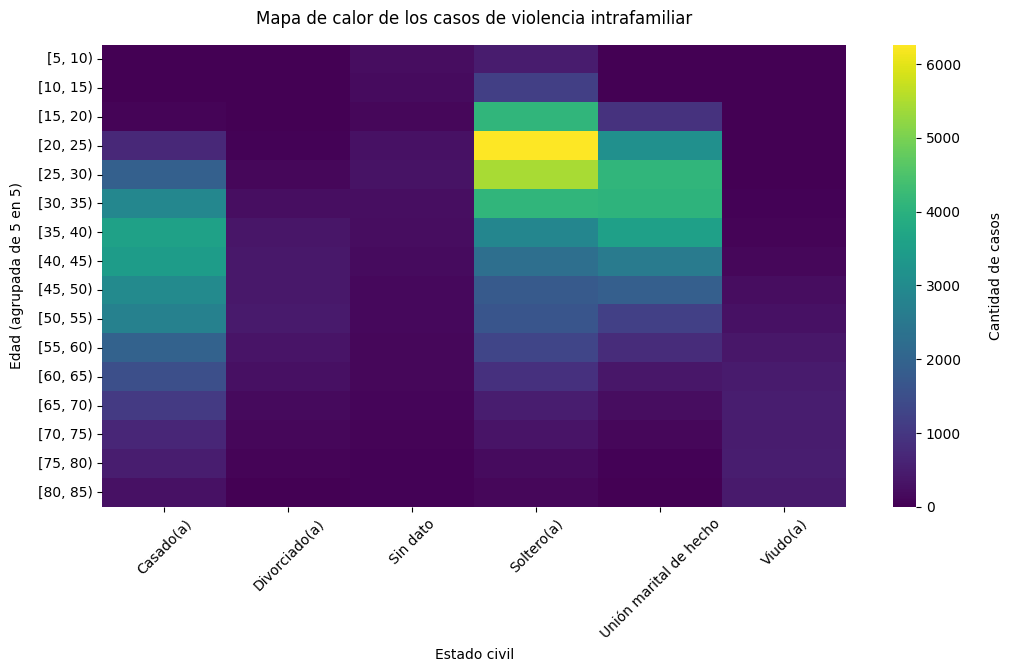

In [ ]:
edad_bins = range(5, 86, 5)
new_df['grupo_edad'] = pd.cut(new_df['edad'], bins=edad_bins, right=False)
heatmap_data = new_df.pivot_table(index='grupo_edad', columns='estado_civil', aggfunc='size', fill_value=0)
heatmap_data = heatmap_data.fillna(0).astype(int)
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap='viridis', cbar=True, vmin=heatmap_data.values.max(), vmax=heatmap_data.values.min())
plt.title('Mapa de calor de los casos de violencia intrafamiliar', pad=15)
plt.xlabel('Estado civil', labelpad=5)
plt.ylabel('Edad (agrupada de 5 en 5)', labelpad=10)
cbar = plt.gca().collections[0].colorbar
cbar.set_label('Cantidad de casos', labelpad=20)
plt.xticks(rotation=45)
#plt.savefig("mapa_calor_edad_vícitma_estado_civil.png", bbox_inches=('tight'))
plt.show()

- Para definir los límites de los intervalos de edad en los que se agruparán los datos, se usa edad_bins = range(5, 86, 5). En este caso, los intervalos de edad comienzan en 5 y terminan en 85, con incrementos de 5 años.
- Con new_df['grupo_edad'] = pd.cut(new_df['edad'], bins=edad_bins, right=False), se crea una nueva columna en el DataFrame new_df llamada 'grupo_edad' que asigna a cada registro la categoría de edad correspondiente según los intervalos definidos en edad_bins. La opción right=False significa que el intervalo no incluye el valor final (por ejemplo, [5, 10) para el primer intervalo).
- Para diseñar el gráfico, se indica heatmap_data = new_df.pivot_table(index='grupo_edad', columns='estado_civil', aggfunc='size', fill_value=0). La función pivot_table crea una tabla que muestra la cantidad de casos de violencia intrafamiliar agrupados por 'grupo_edad' en las filas y 'estado_civil' en las columnas. La función 'size' se utiliza para contar la cantidad de casos en cada combinación de grupo de edad y estado civil. Se llena con 0 en caso de que no haya datos para alguna combinación.
- Para crear el gráfico, sns.heatmap(heatmap_data, cmap='viridis', cbar=True, vmin=heatmap_data.values.max(), vmax=heatmap_data.values.min()),  utiliza la función heatmap de Seaborn para visualizar la tabla de datos heatmap_data. Los argumentos incluyen el mapa de colores (cmap), la visualización de la barra de colores (cbar), y los valores mínimos y máximos de la escala de colores. vmin y vmax se establecen para que la escala de colores muestre los valores de la tabla correctamente.
---
- Como ya se ha visto antes, resaltan los datos de víctimas solteras, casadas, y en una unión marital de hecho. No obstante, las personas solteras que resportan más datos, se ubica entre los 15 y los 30 años, las personas casadas se ubican con mayor intensidad entre los 25 y los 35; y las personas en una unión marital de hecho, resaltan entre los 35 y los 45.
- En general, la mayoría de las víctimas tienen menos de 70 años.
- Hay que ver que las víctimas más jóvenes, corresponden a la categoría de solteros, siendo personas que sufren violencia intrafamiliar por parte de alguien distinto a su pareja (en estas edades, suelen ser los padres, los abuelos o los tíos).
- La categoría que reporta más casos que involucran a víctimas mayores de 50, es la de casados.


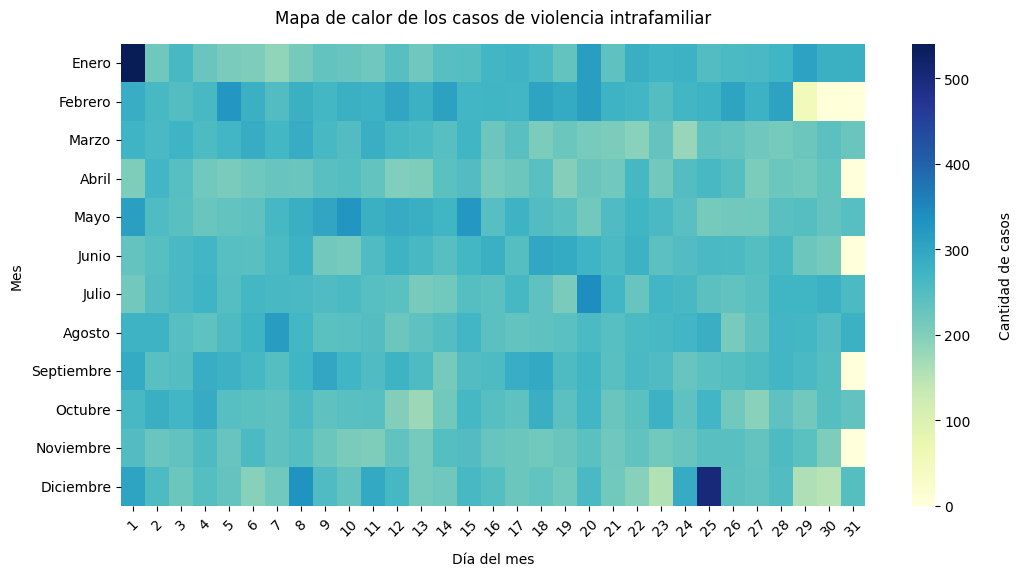

In [ ]:
heatmap_data = new_df.pivot_table(index='mes', columns='dia', aggfunc='size', fill_value=0)
heatmap_data = heatmap_data.fillna(0).astype(int)
meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']
plt.figure(figsize=(12, 6))
ax = sns.heatmap(heatmap_data, cmap='YlGnBu', cbar=True, vmin=heatmap_data.values.min(), vmax=heatmap_data.values.max())
plt.title('Mapa de calor de los casos de violencia intrafamiliar', pad=15)
plt.xlabel('Día del mes', labelpad=10)
plt.ylabel('Mes', labelpad=5)
ax.set_yticklabels(meses, rotation=0)
cbar = plt.gca().collections[0].colorbar
cbar.set_label('Cantidad de casos', labelpad=20)
plt.xticks(rotation=45)
#plt.savefig("mapa_calor_mes_día.png", bbox_inches=('tight'))
plt.show()

- Se hace el mismo procedimiento previamente descrito, solo que se cambian las variables utilizadas y el color del mapa.
---
*   Se puede observar que los días que registran más solicitudes de protección por casos de violencia intrafamiliar son días de fiesta. Por ejemplo, el 25 de diciembre y el primero de enero son los que mayor densidad de solocitudes muestran; y se puede ver que días como el 8 de diciembre (festividad de las velas), el 15 de mayo (día del maestro), 20 de julio (fiestas de la independencia), 1 de mayo (día del trabajo) entre otros, se presentan más casos que en otros días.
*   Esta información es muy importante, pues permite hacer un análisis de los patrones de comportamiento que se dan en lo días festivos, así como delinea un problema que permite empezar a buscar posibles explicaciones. Es decir, este panórama permite preguntarse por qué los días festivos se dan más casos de violencia intrafamiliar y de solicitudes de portección, bien sea por el tiempo libre que se pasa en el hogar, por el alcohol que se puede o no consumir en estos días, u otros motivos por los que habría que indagar.

